# 04 — Diagnóstico: por que a reflexão não bate o baseline (LogiQA2, validação)

Mesmo diagnóstico de `03_diagnostico_reflexao_arc_validacao.ipynb` (ver
[[reflection_mcq_diagnostico_notebook]] na memória do projeto), agora para o **LogiQA2** em vez
do ARC. A estrutura é idêntica de propósito — mesma metodologia, mesmas métricas, prompts nas
mesmas posições — para que os dois diagnósticos fiquem comparáveis célula a célula. O que muda
é específico do dataset, marcado ao longo do notebook.

**Diferenças que importam em relação ao notebook do ARC:**

- LogiQA2 é `problem_type="process"` (dedução lógica), não `"knowledge"`: cada questão tem uma
  premissa (`context`) que É o argumento a analisar — sem ela a pergunta não faz sentido. Isso já
  é tratado pelo `format_question`/embedding de sempre (contexto + pergunta), sem código
  específico do dataset.
- **Escala muito maior**: split de treino com 372 itens (vs. 286 do ARC) e — o que pesa de
  verdade — split de **validação com 1.565 itens** (vs. 298 do ARC). Rodar a mesma grade
  `k × threshold × depth` inteira sobre 1.565 itens multiplicaria o custo de GPU por ~5× em
  relação ao ARC. Por isso este notebook amostra o split de validação para a etapa da GRADE (só
  ela — o baseline roda sobre os 1.565 itens inteiros, é barato: 1 geração por item) usando o
  mesmo método de dimensionamento amostral que o projeto já usa para escolher o tamanho do
  treino (`rmcq.common.cochran_sample_size` / `stratified_sample`, fórmula de Cochran — ver
  `Caderno de Experimentos.md`, seção 2). Isso é uma escolha PRINCIPIADA de tamanho, não um corte
  arbitrário, e pode ser desligada (`USE_GRID_SAMPLE = False`) se você tiver orçamento de GPU
  para a grade inteira.
- Hipótese específica a testar aqui (diferente do ARC): em raciocínio lógico, duas questões
  podem ser semanticamente "parecidas" no embedding (mesmo domínio, vocabulário parecido) sem
  compartilhar a mesma estrutura de argumento/falácia — o que faria a reflexão recuperada por
  similaridade textual transferir PIOR aqui do que no ARC, onde "parecido" tende a significar
  "mesmo fato de ciência". Vale comparar o gráfico de transferability dos dois notebooks lado a
  lado no final.

**O que NÃO muda** (ver notebook do ARC para a justificativa de cada decisão): self-reflection
por padrão (`TEACHERS_PER_STUDENT`), os dois alunos ativos (`phi4-mini`, `llama3-8b`), as duas
profundidades de reflexão já geradas (`simple`, `complex`), prompts como cópias locais editáveis
com verificação de sincronia contra `rmcq.common`, `k` e limiar de similaridade escolhidos a
partir dos quantis da distribuição real (não chutados), `SMOKE_TEST` com `StubBackend` para
validar a canalização antes de gastar GPU de verdade.


## 0. Setup

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"  # desativa GPU para testes rápidos

In [2]:
import sys
import warnings
from itertools import product
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))  # pacote rmcq

import rmcq  # carrega o .env antes de qualquer import de torch/transformers/vllm
print(rmcq.env_summary())

from rmcq.backends import GenParams, get_backend
from rmcq.common import (
    cochran_sample_size, make_record, read_jsonl, stratified_sample, write_jsonl,
)  # utilitários, não prompts
from rmcq.config import (
    COCHRAN_CONFIDENCE, COCHRAN_FINITE_CORRECTION, COCHRAN_MARGIN, COCHRAN_PROPORTION,
    COCHRAN_STRATIFY_BY, EMBED_BATCH_SIZE, EMBEDDER, HF_HOME, INDEX_DIR, RESULTS_DIR, SEED,
    STUDENT_GEN, hf_token,
)
from rmcq.data import baseline_path, index_paths, load_split
from rmcq.stages.analyze import SIM_BINS, accuracy_block, transferability, utility
from rmcq.store import JsonlStore, Timer, get_logger, progress

log = get_logger(__name__)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (7, 4)

DATASET = "logiqa2"
STUDENTS = ["phi4-mini", "llama3-8b"]   # alunos ativos em rmcq.config.ACTIVE_MODELS
DEPTHS = ["simple", "complex"]           # as duas profundidades de reflexão já geradas

# --- controles de execução ---------------------------------------------------
# Rode primeiro com SMOKE_TEST = True: troca o backend real pelo StubBackend
# (determinístico, sem GPU, ver rmcq/backends/stub.py) e limita a poucos itens.
# Serve para validar a canalização inteira (prompts, recuperação, gravação,
# consolidação, gráficos) em segundos antes de gastar horas de GPU de verdade.
SMOKE_TEST = False
SMOKE_LIMIT = 8

BACKEND_KIND = "stub" if SMOKE_TEST else None   # None = usa RMCQ_BACKEND do .env (vllm)
RUN_LIMIT = SMOKE_LIMIT if SMOKE_TEST else None

print(f"dataset={DATASET}  students={STUDENTS}  depths={DEPTHS}")
print(f"SMOKE_TEST={SMOKE_TEST}  backend_kind={BACKEND_KIND!r}  limit={RUN_LIMIT}")


.env | CUDA_VISIBLE_DEVICES='2' | backend=vllm
dataset=logiqa2  students=['phi4-mini', 'llama3-8b']  depths=['simple', 'complex']
SMOKE_TEST=False  backend_kind=None  limit=None


## 1. Dataset — LogiQA2, split de validação

`rmcq.data.load_split` lê de `data/splits/logiqa2/validation.jsonl` (1.565 itens — idêntico ao
`data/processed/logiqa2/validation.jsonl`, conferido abaixo). Diferente do ARC, aqui `context`
nunca é nulo: é a premissa do argumento, parte inseparável da questão.


In [3]:
val_items = load_split(DATASET, "validation")
train_items = load_split(DATASET, "train")  # 372 itens: os que têm reflexão gerada

processed_path = ROOT / "data" / "processed" / DATASET / "validation.jsonl"
processed_items = read_jsonl(processed_path)
assert [i["uid"] for i in processed_items] == [i["uid"] for i in val_items], (
    f"data/processed/{DATASET}/validation.jsonl e data/splits/{DATASET}/validation.jsonl "
    "divergiram — investigue antes de continuar."
)

print(f"validação: {len(val_items)} itens   |   treino (com reflexão): {len(train_items)} itens")
print(f"itens com contexto (premissa): {sum(1 for i in val_items if i.get('context'))}/{len(val_items)}")
pd.DataFrame([
    {
        "uid": i["uid"],
        "premissa": (i["context"] or "")[:60] + "...",
        "pergunta": i["question"][:60] + ("..." if len(i["question"]) > 60 else ""),
        "n_opções": i["num_choices"],
        "gabarito": i["answerKey"],
    }
    for i in val_items[:5]
])


validação: 1565 itens   |   treino (com reflexão): 372 itens
itens com contexto (premissa): 1565/1565


,uid,premissa,pergunta,n_opções,gabarito
0,logiqa2-validation-000000,Jupiter is a gas giant planet and the largest ...,"Which of the followings, if true, can best sup...",4,D
1,logiqa2-validation-000001,"All Anxi people are vegetarians, while all Zhe...",Which of the followings can be infered,4,D
2,logiqa2-validation-000002,The medieval Arabs had many manuscripts of the...,"Which of the following options, if true, stron...",4,A
3,logiqa2-validation-000003,"In the past five years, the percentage of mone...","Which one of the following, if true, allows th...",4,D
4,logiqa2-validation-000004,"Mayor: Four years ago, when we reorganized the...","Which of the following, if true, most seriousl...",4,B


## 2. Prompt de baseline (sem reflexão) — editável

Cópia local de `ANSWER_PROMPT`/`build_answer_prompt` de `rmcq/common.py`, igual ao notebook do
ARC. `format_question` já prefixa o contexto quando ele existe — nenhuma mudança precisa aqui
por causa do LogiQA2 ter premissa. Edite à vontade; a célula seguinte só avisa se divergir do
pacote, nunca trava.


In [4]:
ANSWER_PROMPT = """You are answering a multiple-choice question.

Question: {question}

Options:
{options}

Instructions:
- Think step by step before answering.
- Choose exactly one option.
- End your response with this exact line, and nothing after it:
FINAL ANSWER: <letter>"""


def format_options(choices):
    return "\n".join(f"{c['label']}) {c['text']}" for c in choices)


def format_question(item):
    context = item.get("context")
    if context:
        return f"{context.strip()}\n\n{item['question'].strip()}"
    return item["question"].strip()


def build_answer_prompt(item):
    return ANSWER_PROMPT.format(question=format_question(item), options=format_options(item["choices"]))


print(build_answer_prompt(val_items[0]))


You are answering a multiple-choice question.

Question: Jupiter is a gas giant planet and the largest planet in the solar system. Its mass is 2.5 times the total mass of the other seven planets in the solar system. Observations have found that most of the more than 70 moons surrounding Jupiter are composed of water ice. Therefore, Jupiter's atmosphere should contain a considerable amount of water.

Which of the followings, if true, can best support the above statement?

Options:
A) After hundreds of millions of years, the satellite may slowly fall onto the planet.
B) Many of the water in interstellar space exists in gaseous form.
C) Uranus is also a gas giant planet, and it has been confirmed that it contains a lot of water ice.
D) The satellite and the planets around it were formed from the same gas and dust at the same time.

Instructions:
- Think step by step before answering.
- Choose exactly one option.
- End your response with this exact line, and nothing after it:
FINAL ANSWER:

In [5]:
# Verificação de sincronia (não trava, só avisa) -----------------------------
from rmcq import common as _common

_diffs = []
if ANSWER_PROMPT != _common.ANSWER_PROMPT:
    _diffs.append("ANSWER_PROMPT")
if build_answer_prompt(val_items[0]) != _common.build_answer_prompt(val_items[0]):
    _diffs.append("build_answer_prompt(...)")

if _diffs:
    warnings.warn(f"cópias locais divergem de rmcq.common em: {_diffs} (pode ser intencional)")
else:
    print("prompt local idêntico a rmcq.common.ANSWER_PROMPT nesta execução.")


prompt local idêntico a rmcq.common.ANSWER_PROMPT nesta execução.


## 3. Baseline novo: validação sem reflexão

Não existe ainda (só `logiqa2_train.jsonl` e `logiqa2_test.jsonl`). Roda sobre os **1.565 itens
inteiros** — diferente da grade (seção 5), o baseline é 1 geração por item, então o custo aqui
não escala com `k`/`threshold`/profundidade. Grava no mesmo layout do resto do pipeline
(`rmcq.data.baseline_path`), retomável do jeito de sempre.


In [6]:
def run_baseline_validation(students, limit=None, backend_kind=None):
    params = GenParams.from_config(STUDENT_GEN, seed=SEED)
    stats = {"generated": 0, "elapsed_s": 0.0}

    items = val_items[:limit] if limit else val_items

    for model in students:
        store = JsonlStore(baseline_path(model, DATASET, "validation"))
        done = store.done_keys()
        pending = [i for i in items if i["uid"] not in done]
        if not pending:
            log.info("[%s] baseline de validação já completo (%d itens)", model, len(items))
            continue

        with Timer() as timer, get_backend(model, backend_kind) as backend:
            prompts = [build_answer_prompt(i) for i in pending]
            gens = backend.generate(prompts, params, desc=f"{model} baseline {DATASET}/validation")

            records = [
                make_record(
                    item, stage="baseline", condition="no_reflection", student_model=model,
                    prompt=prompt, output=gen.text,
                    prompt_tokens=gen.prompt_tokens, completion_tokens=gen.completion_tokens,
                    latency_s=gen.latency_s, seed=SEED, temperature=params.temperature,
                )
                for item, prompt, gen in zip(pending, prompts, gens)
            ]
            store.append(records)
            stats["generated"] += len(records)
            n_ok = sum(1 for r in records if r.is_correct)
            log.info("[%s] gravado %d, acerto %.1f%%", model, len(records), 100 * n_ok / max(len(records), 1))
        stats["elapsed_s"] += timer.elapsed

    return stats


run_baseline_validation(STUDENTS, limit=RUN_LIMIT, backend_kind=BACKEND_KIND)


{'generated': 0, 'elapsed_s': 0.0}

In [22]:
def load_rows(path):
    store = JsonlStore(path)
    return {r["uid"]: r for r in store.read_all()} if store.exists() else {}


baseline_rows = {s: load_rows(baseline_path(s, DATASET, "validation")) for s in STUDENTS}

baseline_summary = pd.DataFrame([
    {"student": s, **accuracy_block(list(rows.values()))}
    for s, rows in baseline_rows.items()
])
baseline_summary[["student", "n", "n_answered", "n_abstained", "n_correct", "accuracy", "accuracy_answered", "format_adherence"]]


,student,n,n_answered,n_abstained,n_correct,accuracy,accuracy_answered,format_adherence
0,phi4-mini,1565,1548,17,829,0.5297,0.5355,0.9891
1,llama3-8b,1565,1559,6,857,0.5476,0.5497,0.9923


## 4. Similaridade treino ↔ validação

Igual ao ARC: calculamos treino×validação do zero (o índice oficial só tem treino×teste),
reaproveitando o embedding de treino já cacheado no índice oficial quando os uids batem (aqui,
os 372 itens de `data/splits/logiqa2/train.jsonl`). Só os 1.565 embeddings de validação são
novos — ainda assim, mais 5× o volume do ARC, então esta célula demora mais.


In [7]:
BGE_QUERY_PREFIX = "Represent this sentence for searching relevant passages: "


def needs_query_prefix(embedder_name):
    return "bge" in embedder_name.lower() and "en" in embedder_name.lower()


def embed_text(item):
    """Texto representado no índice: contexto (premissa) + pergunta, sem as alternativas."""
    context = (item.get("context") or "").strip()
    question = item["question"].strip()
    return f"{context}\n\n{question}".strip() if context else question


FORCE_RECOMPUTE_SIM = False  # True para ignorar qualquer cache e recalcular tudo

SIM_CACHE_DIR = INDEX_DIR / EMBEDDER.replace("/", "_") / DATASET
SIM_CACHE_DIR.mkdir(parents=True, exist_ok=True)
SIM_CACHE_PATH = SIM_CACHE_DIR / "train_validation_sim.npz"

train_by_uid = {i["uid"]: i for i in train_items}
official_index = index_paths(DATASET, EMBEDDER)


In [8]:
if SIM_CACHE_PATH.exists() and not FORCE_RECOMPUTE_SIM:
    _blob = np.load(SIM_CACHE_PATH, allow_pickle=False)
    sim_matrix = _blob["sim"]
    train_uids = [str(u) for u in _blob["train_uids"]]
    val_uids = [str(u) for u in _blob["val_uids"]]
    print(f"similaridade carregada do cache: {SIM_CACHE_PATH}")

else:
    # Reaproveita o embedding de treino do índice oficial (train × test) quando existir:
    # o embedding de uma questão não depende de contra o que ela vai ser comparada.
    if official_index["train_emb"].exists() and official_index["neighbors"].exists():
        _nb = np.load(official_index["neighbors"], allow_pickle=False)
        _official_train_uids = [str(u) for u in _nb["train_uids"]]
        if set(_official_train_uids) == set(train_by_uid):
            train_emb = np.load(official_index["train_emb"])
            train_uids = _official_train_uids
            print(f"reaproveitando embeddings de treino do índice oficial: {official_index['train_emb']}")
            need_train_embed = False
        else:
            warnings.warn(
                f"uids do índice oficial não batem com data/splits/{DATASET}/train.jsonl atual; "
                "recalculando embeddings de treino do zero."
            )
            need_train_embed = True
    else:
        need_train_embed = True

    from sentence_transformers import SentenceTransformer

    embedder_model = SentenceTransformer(EMBEDDER, cache_folder=str(HF_HOME), token=hf_token())

    if need_train_embed:
        train_uids = [i["uid"] for i in train_items]
        train_texts = [embed_text(i) for i in train_items]
        train_emb = embedder_model.encode(
            train_texts, batch_size=EMBED_BATCH_SIZE, normalize_embeddings=True,
            show_progress_bar=True, convert_to_numpy=True,
        )

    val_uids = [i["uid"] for i in val_items]
    val_texts = [embed_text(i) for i in val_items]
    if needs_query_prefix(EMBEDDER):
        val_texts = [BGE_QUERY_PREFIX + t for t in val_texts]
    val_emb = embedder_model.encode(
        val_texts, batch_size=EMBED_BATCH_SIZE, normalize_embeddings=True,
        show_progress_bar=True, convert_to_numpy=True,
    )

    sim_matrix = val_emb @ train_emb.T  # (n_val, n_train), embeddings normalizados => cosseno
    np.savez_compressed(
        SIM_CACHE_PATH,
        sim=sim_matrix.astype("float32"),
        train_uids=np.array(train_uids),
        val_uids=np.array(val_uids),
    )
    print(f"similaridade calculada e cacheada em: {SIM_CACHE_PATH}")

val_uid_to_row = {u: i for i, u in enumerate(val_uids)}
train_uid_to_col = {u: i for i, u in enumerate(train_uids)}
print(f"sim_matrix: {sim_matrix.shape}  (validação × treino)")


similaridade carregada do cache: /home/rodrigo.flexa/Reflection-MCQ/results/index/BAAI_bge-large-en-v1.5/logiqa2/train_validation_sim.npz
sim_matrix: (1565, 372)  (validação × treino)


count    1565.000000
mean        0.637782
std         0.050666
min         0.492598
10%         0.580346
25%         0.606650
50%         0.636585
75%         0.665405
90%         0.693168
95%         0.712578
max         0.988197
Name: top1_similarity, dtype: float64

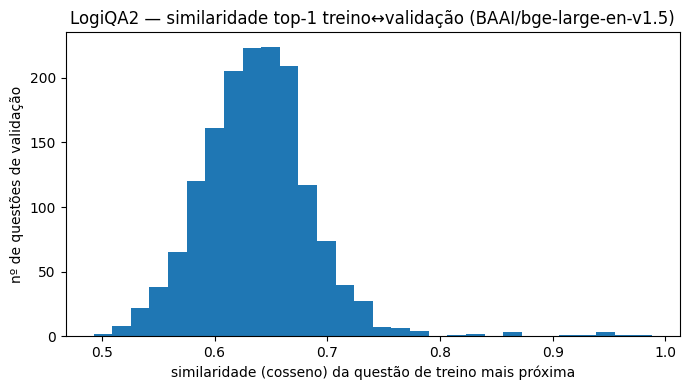

In [9]:
top1_sim = sim_matrix.max(axis=1)

display(pd.Series(top1_sim, name="top1_similarity").describe(percentiles=[.1, .25, .5, .75, .9, .95]))

fig, ax = plt.subplots()
ax.hist(top1_sim, bins=30)
ax.set_xlabel("similaridade (cosseno) da questão de treino mais próxima")
ax.set_ylabel("nº de questões de validação")
ax.set_title(f"LogiQA2 — similaridade top-1 treino↔validação ({EMBEDDER})")
plt.tight_layout()
plt.show()


## 5. Escolha de `k` e do limiar de similaridade

Mesma lógica data-driven do ARC: os limiares candidatos vêm dos quartis da distribuição de
similaridade top-1 acima (0 = sem filtro, igual ao comportamento atual do pipeline). `k=2` entra
por padrão junto com 1 e 3, como pedido.


In [10]:
K_GRID = [1, 2, 3]

_quantiles = [0.0, 0.25, 0.5, 0.75]
THRESHOLD_GRID = sorted({0.0} | {round(float(np.quantile(top1_sim, q)), 2) for q in _quantiles})

print(f"K_GRID = {K_GRID}")
print(f"THRESHOLD_GRID = {THRESHOLD_GRID}  (quantis {_quantiles} da similaridade top-1)")
print(
    f"\n{len(STUDENTS)} alunos × {len(DEPTHS)} profundidades × {len(K_GRID)} valores de k × "
    f"{len(THRESHOLD_GRID)} limiares = "
    f"{len(STUDENTS) * len(DEPTHS) * len(K_GRID) * len(THRESHOLD_GRID)} configurações"
)


K_GRID = [1, 2, 3]
THRESHOLD_GRID = [0.0, 0.49, 0.61, 0.64, 0.67]  (quantis [0.0, 0.25, 0.5, 0.75] da similaridade top-1)

2 alunos × 2 profundidades × 3 valores de k × 5 limiares = 60 configurações


## 6. Amostragem do split de validação para a grade

1.565 itens de validação × as configurações acima ficaria caro demais para rodar sem critério
(ver célula seguinte para o número exato). O baseline (seção 3) já rodou sobre os 1.565 itens
inteiros — isso não muda. Aqui decidimos quantos itens entram na GRADE (`k × threshold ×
profundidade`), com o mesmo método que o projeto já usa para dimensionar amostra
(`Caderno de Experimentos.md`, seção 2 — fórmula de Cochran, `rmcq.common.cochran_sample_size`),
e uma amostra estratificada por gabarito (`stratified_sample`) para não enviesar a distribuição
de respostas corretas.

Para rodar a grade sobre os 1.565 itens inteiros (mais fiel, muito mais caro), mude
`USE_GRID_SAMPLE = False`.


In [11]:
USE_GRID_SAMPLE = True

if USE_GRID_SAMPLE:
    _cochran = cochran_sample_size(
        population=len(val_items),
        confidence=COCHRAN_CONFIDENCE,
        margin=COCHRAN_MARGIN,
        proportion=COCHRAN_PROPORTION,
        finite_correction=COCHRAN_FINITE_CORRECTION,
    )
    grid_items = stratified_sample(val_items, _cochran["n"], stratify_by=COCHRAN_STRATIFY_BY, seed=SEED)
    print(f"Cochran: população={_cochran['population']}, n={_cochran['n']} (95% confiança, margem 5pp)")
else:
    grid_items = val_items

grid_uids = [i["uid"] for i in grid_items]

n_items_grid = len(grid_items) if not RUN_LIMIT else min(RUN_LIMIT, len(grid_items))
_n_configs = len(STUDENTS) * len(DEPTHS) * len(K_GRID) * len(THRESHOLD_GRID)
print(f"itens na grade: {len(grid_items)} de {len(val_items)} ({100 * len(grid_items) / len(val_items):.1f}%)")
print(f"{_n_configs} configurações × {n_items_grid} itens = {_n_configs * n_items_grid:,} gerações na grade")


Cochran: população=1565, n=309 (95% confiança, margem 5pp)
itens na grade: 309 de 1565 (19.7%)
60 configurações × 309 itens = 18,540 gerações na grade


## 7. Recuperação (k, threshold) — com rastreio de quantas reflexões vêm de fato

`retrieve_neighbors` devolve no máximo `k` vizinhos de treino com similaridade ≥ `threshold`,
restritos aos uids que têm reflexão de fato gravada (`allowed_train_uids`), em ordem
**crescente** de similaridade — é a ordem que `build_notes_block` (seção seguinte) espera: a
nota mais parecida fica por último, imediatamente antes da questão nova, que é onde um decoder
causal atende mais. Se a lista vier vazia, a etapa 8 cai de
volta no prompt de baseline puro, exatamente como pedido.


In [12]:
def retrieve_neighbors(sims_row, train_uids, k, threshold, allowed_train_uids=None):
    order = np.argsort(-sims_row)  # do mais similar para o menos
    picked = []
    for idx in order:
        sim = float(sims_row[idx])
        if sim < threshold:
            break  # descendente: nada depois disso passa do limiar
        uid = train_uids[idx]
        if allowed_train_uids is not None and uid not in allowed_train_uids:
            continue
        picked.append((uid, sim))
        if len(picked) >= k:
            break
    picked.reverse()  # crescente
    return picked


def reflections_path_local(student, teacher, depth):
    return RESULTS_DIR / "reflections" / f"{student}__{teacher}__{depth}" / f"{DATASET}.jsonl"


def load_reflections_local(student, teacher, depth):
    """Reflexões de treino indexadas por uid, na mesma interface de rmcq.stages.reflect.load_reflections."""
    path = reflections_path_local(student, teacher, depth)
    if not path.exists():
        raise FileNotFoundError(f"reflexões ausentes: {path}")
    return {r["uid"]: r for r in read_jsonl(path)}


# Só self-reflection (professor == aluno) por padrão — é o que foi pedido: cada aluno
# reaproveita as próprias reflexões de treino. Para incluir reflexão externa, basta
# adicionar pares (aluno, professor) diferentes aqui.
TEACHERS_PER_STUDENT = {s: [s] for s in STUDENTS}

REFLECTIONS = {
    (student, teacher, depth): load_reflections_local(student, teacher, depth)
    for student in STUDENTS
    for teacher in TEACHERS_PER_STUDENT[student]
    for depth in DEPTHS
}
print(f"{len(REFLECTIONS)} conjuntos de reflexão carregados: {list(REFLECTIONS.keys())}")


4 conjuntos de reflexão carregados: [('phi4-mini', 'phi4-mini', 'simple'), ('phi4-mini', 'phi4-mini', 'complex'), ('llama3-8b', 'llama3-8b', 'simple'), ('llama3-8b', 'llama3-8b', 'complex')]


### Os prompts que geraram estas reflexões (histórico, só leitura)

As reflexões em `results/reflections/` já existem; este notebook não as regera. Os quatro
prompts abaixo são os que as produziram — estão aqui porque metade do diagnóstico é olhar
para o texto que o professor foi instruído a escrever e perguntar se ele **transfere** para
outra questão. Editar esta célula não muda nada: para mudar a reflexão é preciso reescrever
`REFLECTION_PROMPTS` em `rmcq/common.py`, apagar o diretório correspondente e rodar
`python -m rmcq reflect` de novo.


In [13]:
for (_depth, _persp), _text in sorted(_common.REFLECTION_PROMPTS.items()):
    if _depth not in DEPTHS:
        continue
    print("=" * 78)
    print(f"REFLECTION_PROMPTS[({_depth!r}, {_persp!r})]   "
          f"— {'autorreflexão (aluno == professor)' if _persp == 'student' else 'professor externo'}")
    print("=" * 78)
    print(_text)
    print()


REFLECTION_PROMPTS[('complex', 'student')]   — autorreflexão (aluno == professor)
You are given:
1 - The original multiple-choice question.
2 - Your previous answer.
3 - Feedback indicating whether your answer was correct or incorrect.

Write a detailed reflection on your previous response. Analyze:
- The reasoning strategy you used to reach your answer.
- The evidence or cues from the question that influenced your decision.
- Any assumptions, heuristics, or uncertainties that affected your judgment.
- How the feedback confirms or contradicts your reasoning.
- Whether your conclusion depended on missing knowledge, incorrect interpretation, overconfidence, or insufficient evaluation of alternatives.
- How you would improve your reasoning process for similar problems in the future.

If the answer was correct, explain which parts of your reasoning were reliable and whether your confidence was appropriately calibrated.
If the answer was incorrect, explain what aspect of your reasoning shou

In [14]:
# Pré-visualização SEM chamar nenhum modelo: quantas reflexões cada (k, threshold) realmente
# entrega, em média, e em que fração dos itens da grade a busca não encontra NADA acima do
# limiar (cai no baseline). Sobre grid_uids — o que a grade vai de fato rodar.

coverage_rows = []
for student in STUDENTS:
    for teacher in TEACHERS_PER_STUDENT[student]:
        for depth in DEPTHS:
            refl = REFLECTIONS[(student, teacher, depth)]
            allowed = {u for u, r in refl.items() if r.get("reflection_text")}
            for k in K_GRID:
                for threshold in THRESHOLD_GRID:
                    counts = np.array([
                        len(retrieve_neighbors(sim_matrix[val_uid_to_row[u]], train_uids, k, threshold, allowed))
                        for u in grid_uids
                    ])
                    coverage_rows.append({
                        "student": student, "teacher": teacher, "depth": depth,
                        "k": k, "threshold": threshold,
                        "mean_retrieved": counts.mean(),
                        "pct_full_k": (counts == k).mean(),
                        "pct_zero_fallback_baseline": (counts == 0).mean(),
                    })

coverage_df = pd.DataFrame(coverage_rows)
coverage_df.round(3)


,student,teacher,depth,k,threshold,mean_retrieved,pct_full_k,pct_zero_fallback_baseline
0,phi4-mini,phi4-mini,simple,1,0.00,1.000,1.000,0.000
1,phi4-mini,phi4-mini,simple,1,0.49,1.000,1.000,0.000
2,phi4-mini,phi4-mini,simple,1,0.61,0.709,0.709,0.291
3,phi4-mini,phi4-mini,simple,1,0.64,0.482,0.482,0.518
4,phi4-mini,phi4-mini,simple,1,0.67,0.201,0.201,0.799
5,phi4-mini,phi4-mini,simple,2,0.00,2.000,1.000,0.000
6,phi4-mini,phi4-mini,simple,2,0.49,2.000,1.000,0.000
7,phi4-mini,phi4-mini,simple,2,0.61,1.256,0.547,0.291
8,phi4-mini,phi4-mini,simple,2,0.64,0.754,0.272,0.518
9,phi4-mini,phi4-mini,simple,2,0.67,0.236,0.036,0.799


## 8. Prompt de avaliação com reflexões recuperadas — editável

**Tudo que entra no prompt está nas duas células abaixo.** Nada de prompt é importado de
`rmcq/common.py`: os textos ficam na primeira célula (é o que você edita) e as
transformações aplicadas a cada reflexão ficam na segunda. A célula de verificação compara
o resultado com o `rmcq.common.build_eval_prompt` versão `v2` e só **avisa** se divergir —
divergir é o ponto do notebook.

Layout `v2`, reescrito para modelos pequenos (phi4-mini, llama3-8b). Cada decisão veio de um
número medido nas reflexões deste repositório:

| decisão | por quê |
|---|---|
| enquadramento primeiro, questão e formato de saída por último | no layout antigo as lições abriam o prompt: o modelo lia até 615 palavras de crítica antes de saber que ia responder uma questão, e a instrução de formato ficava a ~2.000 tokens do início |
| `<notes>` / `<note id="i">` em vez de `[Lesson 1]` + `---` | sem delimitador duro o enunciado de origem compete com o enunciado a responder |
| enunciado de origem **com contexto** (`format_question`), 600 chars, corte em fronteira de frase | a similaridade da seção 4 é calculada sobre contexto + pergunta; injetar só a pergunta deixa a nota sem referente — no LogiQA2, `"Which one of the following is an assumption required?"` sem a premissa não identifica questão nenhuma |
| corte de cada nota em 120 palavras, **pela cabeça** | `complex` tem ~615 palavras de mediana; com k=3 são ~1.850 palavras de referência para uma questão de ~60. A parte que transfere ("Lesson: …", "How to improve: …") fica na **cauda** |
| letras de alternativa → `[letter]` | 50% das reflexões `complex` e 42% das de autorreflexão citam uma letra vinda de **outra** questão, ancorando o aluno numa alternativa da questão nova |

Sem nenhuma reflexão recuperada, o prompt cai **byte a byte** no `ANSWER_PROMPT` da
seção 2 — não existe um terceiro formato para "k pedido mas nada recuperado".


In [15]:
# =========================================================================
# OS TEXTOS DO PROMPT — é isto que você edita
# =========================================================================

NOTES_HEADER = """You are answering a multiple-choice question.

First, some notes from earlier attempts at OTHER questions. They are reference material about how to reason. None of them is about the question below, and none of them contains its answer.

<notes>
{notes}
</notes>

"""

NOTE_BLOCK = """<note id="{i}">
{body}
</note>"""

NOTE_SOURCE = 'This note was written about a different question: "{source_question}"'

NOTE_OUTCOME = {
    True: "The earlier answer to that question was correct.",
    False: "The earlier answer to that question was incorrect.",
}

EVAL_TAIL = """Question: {question}

Options:
{options}

Instructions:
- The notes are advice on how to reason, nothing more. The correct option here may be a different letter than any letter mentioned in a note.
- Think step by step before answering.
- Choose exactly one option.
- End your response with this exact line, and nothing after it:
FINAL ANSWER: <letter>"""


# --- knobs: cada um é uma ablação, ligue e desligue à vontade ---------------
INJECT_SOURCE_QUESTION = True    # o enunciado de origem entra junto de cada nota
TAG_SOURCE_OUTCOME = True        # "the earlier answer to that question was correct/incorrect"
NOTE_MAX_WORDS = 120             # 0 desliga o corte. 120 ~ tamanho de uma reflexão `simple`
NEUTRALIZE_LETTERS = True        # "you selected D" -> "you selected [letter]"
SOURCE_QUESTION_MAX_CHARS = 600  # 0 ou None desliga o corte do enunciado de origem


In [16]:
# =========================================================================
# AS TRANSFORMAÇÕES APLICADAS A CADA REFLEXÃO ANTES DE ELA VIRAR UMA <note>
# =========================================================================
# Cópia local de rmcq/common.py, aqui para poder ser editada — a célula de
# verificação abaixo avisa quando o resultado deixa de bater com o oficial.
import re

_SENTENCE_END = re.compile(r"(?<=[.!?])\s+")
_BULLET = re.compile(r"^\s*(?:[-*•]|\d+[.)])\s")

# "option D", "answer (B)", "chose C" — sempre letra MAIÚSCULA isolada, então o
# artigo "a" e palavras comuns não são atingidos.
_LETTER_MENTIONS = (
    re.compile(r"\b((?:option|choice|answer|alternative|response)s?\s+)\(?([A-H])\)?(?![\w-])"),
    re.compile(r"\b((?:chose|choose|chosen|selected|select|picked|pick|answered)\s+)\(?([A-H])\)?(?![\w-])"),
    re.compile(r"(\s)\(([A-H])\)(?![\w-])"),
)
# Continuação de enumeração: "options [letter], C, and D".
_LETTER_ENUM = re.compile(r"(\[letter\])(,?\s+(?:and|or)\s+|,\s*)([A-H])(?![\w-])")
_LETTER_QUOTED = re.compile(r"([\"“\'])([A-H])([\"”\'])")


def neutralize_option_letters(text):
    """
    "you selected D" -> "you selected [letter]".

    A reflexão foi escrita sobre OUTRA questão, onde "D" era outra coisa. A frase
    continua legível; só perde a âncora numa letra que não tem nada a ver com a
    questão nova. NÃO cobre letra solta sem pista ("arguing that A could be
    possible"): separar isso do artigo "A" daria falso positivo em texto comum.
    """
    for pattern in _LETTER_MENTIONS:
        text = pattern.sub(r"\1[letter]", text)
    text = _LETTER_QUOTED.sub(r"\1[letter]\3", text)
    while True:
        text, n = _LETTER_ENUM.subn(r"\1\2[letter]", text)
        if not n:
            return text


def _text_units(text):
    """Linhas e frases da reflexão, na ordem, sem vazios — a unidade de corte."""
    units = []
    for line in text.splitlines():
        line = line.strip()
        if not line:
            continue
        parts = [p.strip() for p in _SENTENCE_END.split(line) if p.strip()]
        units.extend(parts or [line])
    return units


def compact_reflection(text, max_words=None):
    """
    Limita a reflexão a `max_words` cortando pela CABEÇA.

    A cabeça narra a questão de origem ("Your reasoning centered on a causal
    chain: government policies increased demand...") e a cauda traz o que
    transfere ("Use the negation test for necessary assumptions..."). Cortar
    pela cauda joga fora exatamente a parte reaproveitável.
    """
    max_words = NOTE_MAX_WORDS if max_words is None else max_words
    text = (text or "").strip()
    if max_words <= 0 or len(text.split()) <= max_words:
        return text

    kept, total = [], 0
    for unit in reversed(_text_units(text)):
        n = len(unit.split())
        if kept and total + n > max_words:
            break
        kept.append(unit)
        total += n
    kept.reverse()
    if not kept:
        return " ".join(text.split()[:max_words])
    out = ""
    for unit in kept:
        sep = "\n" if out and _BULLET.match(unit) else (" " if out else "")
        out += sep + unit
    return "(...) " + out


def format_source_question(text, max_chars=None):
    """Enunciado de origem em uma linha, cortado em fronteira de frase."""
    max_chars = SOURCE_QUESTION_MAX_CHARS if max_chars is None else max_chars
    text = " ".join((text or "").split())
    if not max_chars or len(text) <= max_chars:
        return text
    cut = text[:max_chars]
    stop = max(cut.rfind(". "), cut.rfind("? "), cut.rfind("! "))
    return (cut[: stop + 1] if stop > max_chars // 2 else cut.rstrip()) + " (...)"


# --- montagem --------------------------------------------------------------

def build_notes_block(reflections, source_questions=None, source_was_correct=None):
    """As k notas, na ordem em que chegam (similaridade CRESCENTE)."""
    if not reflections:
        return ""

    notes = []
    for i, reflection in enumerate(reflections, start=1):
        lines = []
        if INJECT_SOURCE_QUESTION and source_questions:
            lines.append(NOTE_SOURCE.format(source_question=format_source_question(source_questions[i - 1])))
        if TAG_SOURCE_OUTCOME and source_was_correct:
            outcome = NOTE_OUTCOME.get(source_was_correct[i - 1])
            if outcome:
                lines.append(outcome)

        text = compact_reflection(reflection)
        if NEUTRALIZE_LETTERS:
            text = neutralize_option_letters(text)
        lines.append(text)

        notes.append(NOTE_BLOCK.format(i=i, body="\n".join(lines)))

    return NOTES_HEADER.format(notes="\n\n".join(notes))


def build_eval_prompt(item, reflections, source_questions=None, source_was_correct=None):
    # Sem notas recuperadas o prompt é byte a byte o baseline da seção 2 — é
    # isso que torna a linha de fallback comparável ao baseline.
    if not reflections:
        return build_answer_prompt(item)

    return build_notes_block(reflections, source_questions, source_was_correct) + EVAL_TAIL.format(
        question=format_question(item),
        options=format_options(item["choices"]),
    )


In [17]:
# Verificação de sincronia (não trava, só avisa) -----------------------------
# O kernel pode ter importado rmcq.common ANTES de o arquivo mudar — o Python
# cacheia o módulo, e a comparação abaixo levantaria TypeError com a assinatura
# antiga. Recarregar aqui evita ter que reiniciar o kernel a cada edição.
import importlib

from rmcq import common as _common
_common = importlib.reload(_common)

_sample = val_items[0]
_refl = REFLECTIONS[(STUDENTS[0], STUDENTS[0], "simple")]
_allowed = {u for u, r in _refl.items() if r.get("reflection_text")}
_picked = retrieve_neighbors(sim_matrix[val_uid_to_row[_sample["uid"]]], train_uids, k=2, threshold=0.0, allowed_train_uids=_allowed)
_texts = [_refl[u]["reflection_text"] for u, _ in _picked]
# format_question, não ["question"]: com o contexto, que é sobre o que a
# similaridade da seção 4 foi calculada.
_srcq = [format_question(train_by_uid[u]) for u, _ in _picked]
_srcc = [_refl[u].get("extra", {}).get("source_was_correct") for u, _ in _picked]

_local_prompt = build_eval_prompt(_sample, _texts, _srcq, _srcc)

try:
    _official_prompt = _common.build_eval_prompt(_sample, _texts, _srcq, _srcc, version="v2")
except TypeError:
    # rmcq/common.py ainda sem o prompt v2 (checkout anterior a 26/08/2026).
    _official_prompt = None
    warnings.warn("rmcq.common deste ambiente não conhece o prompt v2; comparação pulada.")

if _official_prompt is None:
    pass
elif _local_prompt != _official_prompt:
    warnings.warn("prompt local diverge de rmcq.common (v2) — intencional se você editou a célula acima")
else:
    print("prompt de avaliação local idêntico a rmcq.common (v2) nesta execução.")

print(f"fallback sem nota == baseline byte a byte: {build_eval_prompt(_sample, []) == build_answer_prompt(_sample)}")

print("\n" + "=" * 78)
print("EXEMPLO — o prompt exato que o aluno recebe (k=2, sem filtro de limiar)")
print("=" * 78 + "\n")
print(_local_prompt)


prompt de avaliação local idêntico a rmcq.common (v2) nesta execução.
fallback sem nota == baseline byte a byte: True

EXEMPLO — o prompt exato que o aluno recebe (k=2, sem filtro de limiar)

You are answering a multiple-choice question.

First, some notes from earlier attempts at OTHER questions. They are reference material about how to reason. None of them is about the question below, and none of them contains its answer.

<notes>
<note id="1">
This note was written about a different question: "Astronaut: Any moon, by definition, orbits some planet in a solar system. So, the moons in solar system S4 all orbit the planet Alpha. The astronaut's conclusion follows logically if which one of the following is assumed?"
The earlier answer to that question was incorrect.
(...) This led me to incorrectly conclude that option [letter] was the best fit. The feedback clearly indicates that I misunderstood the requirement for option [letter] to fully validate the astronaut's conclusion. In this c

### O que cada knob faz, no texto de verdade

A célula abaixo não chama modelo nenhum: ela mostra o efeito de cada knob sobre as
reflexões deste dataset e o custo em tokens de entrada. É o lugar de decidir os valores
antes de gastar GPU na grade.


In [18]:
# Efeito de cada knob, medido nas reflexões deste dataset -------------------
_demo_texts = [r["reflection_text"] for r in _refl.values() if r.get("reflection_text")]

print("tamanho das reflexões (palavras), por profundidade:")
for _depth in DEPTHS:
    _t = [r["reflection_text"] for r in REFLECTIONS[(STUDENTS[0], STUDENTS[0], _depth)].values() if r.get("reflection_text")]
    _w = sorted(len(x.split()) for x in _t)
    _cortadas = sum(1 for x in _t if NOTE_MAX_WORDS and len(x.split()) > NOTE_MAX_WORDS)
    _com_letra = sum(1 for x in _t if neutralize_option_letters(x) != x)
    print(
        f"  {_depth:8s} mediana {_w[len(_w)//2]:4d}  máx {_w[-1]:4d}  |  "
        f"acima de NOTE_MAX_WORDS={NOTE_MAX_WORDS}: {_cortadas}/{len(_t)}  |  "
        f"citam letra de alternativa: {_com_letra}/{len(_t)}"
    )

# Uma reflexão longa, antes e depois do corte -------------------------------
_long = max(_demo_texts, key=lambda x: len(x.split()))
print("\n" + "-" * 78)
print(f"CORTE — reflexão mais longa: {len(_long.split())} palavras")
print("-" * 78)
print("ANTES (primeiras 60 palavras):", " ".join(_long.split()[:60]), "...")
print("\nDEPOIS:", compact_reflection(_long))

# Neutralização de letra ----------------------------------------------------
_with_letter = next((t for t in _demo_texts if neutralize_option_letters(t) != t), None)
if _with_letter:
    import difflib as _difflib
    print("\n" + "-" * 78)
    print("NEUTRALIZAÇÃO DE LETRA — trechos alterados")
    print("-" * 78)
    _a, _b = _with_letter.split(), neutralize_option_letters(_with_letter).split()
    for _op, _i1, _i2, _j1, _j2 in _difflib.SequenceMatcher(None, _a, _b).get_opcodes():
        if _op != "equal":
            print("  ", " ".join(_a[max(0, _i1 - 6):_i2 + 4]), " ->  ", " ".join(_b[max(0, _j1 - 6):_j2 + 4]))

# Custo em tokens de entrada, por configuração ------------------------------
print("\n" + "-" * 78)
print("CUSTO — palavras do prompt de avaliação (proxy de tokens de entrada)")
print("-" * 78)
_base_len = len(build_answer_prompt(_sample).split())
print(f"  baseline (sem nota): {_base_len} palavras")
for _k in K_GRID:
    _p = retrieve_neighbors(sim_matrix[val_uid_to_row[_sample["uid"]]], train_uids, _k, 0.0, _allowed)
    _tx = [_refl[u]["reflection_text"] for u, _ in _p]
    _sq = [format_question(train_by_uid[u]) for u, _ in _p]
    _sc = [_refl[u].get("extra", {}).get("source_was_correct") for u, _ in _p]
    _cortado = len(build_eval_prompt(_sample, _tx, _sq, _sc).split())
    _sem_corte = NOTE_MAX_WORDS
    globals()["NOTE_MAX_WORDS"] = 0
    _bruto = len(build_eval_prompt(_sample, _tx, _sq, _sc).split())
    globals()["NOTE_MAX_WORDS"] = _sem_corte
    print(f"  k={_k}: {_cortado} palavras (sem o corte seriam {_bruto}, ou {_bruto / max(_base_len, 1):.1f}x o baseline)")


tamanho das reflexões (palavras), por profundidade:
  simple   mediana  162  máx  310  |  acima de NOTE_MAX_WORDS=120: 351/372  |  citam letra de alternativa: 160/372
  complex  mediana  384  máx  609  |  acima de NOTE_MAX_WORDS=120: 372/372  |  citam letra de alternativa: 215/372

------------------------------------------------------------------------------
CORTE — reflexão mais longa: 310 palavras
------------------------------------------------------------------------------
ANTES (primeiras 60 palavras): In my previous response, I focused on identifying an option that directly challenges the hypothesis that increased competition for college-educated employees was the primary driver of the income disparity. I chose option B, which suggested that some employees with no college degree were earning incomes comparable to those with a college degree, implying that the income disparity might not be ...

DEPOIS: (...) It challenges me to think more critically about the relationships betwee

## 9. A grade de experimentos

Cada configuração é `(aluno, professor, profundidade, k, threshold)`. Com professor == aluno
(self-reflection) por padrão. Os resultados vão para
`results/diagnostics/{aluno}__{professor}__{profundidade}__k{k}__t{threshold}/{dataset}_validation.jsonl`
— a mesma árvore usada pelo notebook do ARC; o nome do dataset entra no arquivo, não na pasta da
configuração, então os diagnósticos de ARC e LogiQA2 para a mesma combinação de modelo/k/threshold
convivem lado a lado sem colidir.


In [19]:
GRID = [
    {"student": s, "teacher": t, "depth": d, "k": k, "threshold": thr}
    for s in STUDENTS
    for t in TEACHERS_PER_STUDENT[s]
    for d in DEPTHS
    for k in K_GRID
    for thr in THRESHOLD_GRID
]

n_items = len(grid_items) if not RUN_LIMIT else min(RUN_LIMIT, len(grid_items))
print(f"{len(GRID)} configurações × {n_items} itens = {len(GRID) * n_items:,} gerações no total")


def diag_tag(student, teacher, depth, k, threshold):
    t_tag = f"t{threshold:.2f}".replace(".", "p")
    return f"{student}__{teacher}__{depth}__k{k}__{t_tag}"


def diag_eval_path(student, teacher, depth, k, threshold, dataset=DATASET):
    d = RESULTS_DIR / "diagnostics" / diag_tag(student, teacher, depth, k, threshold)
    d.mkdir(parents=True, exist_ok=True)
    return d / f"{dataset}_validation.jsonl"


60 configurações × 309 itens = 18,540 gerações no total


## 10. Rodando a grade

Agrupado por aluno (uma carga de modelo por aluno, igual à etapa 4 do pipeline principal —
`rmcq.stages.evaluate`), com as pendências resolvidas ANTES de carregar cada modelo — um rerun
que já completou tudo para um aluno não carrega o modelo à toa. Retomável: uma configuração já
gravada não é refeita.

Com `SMOKE_TEST = True` (célula de setup), isto roda em segundos com o `StubBackend`. Para a
rodada de verdade, mude `SMOKE_TEST = False`, reinicie a partir da célula de setup e rode esta
célula — com `USE_GRID_SAMPLE = True` (padrão) o volume fica comparável ao do ARC; com
`USE_GRID_SAMPLE = False`, ~5× maior.


In [20]:
def run_diagnostic_grid(grid, pool_items, limit=None, backend_kind=None):
    from collections import defaultdict

    items = pool_items[:limit] if limit else pool_items
    items_by_uid = {i["uid"]: i for i in items}
    use_uids = list(items_by_uid)

    by_student = defaultdict(list)
    for cfg in grid:
        by_student[cfg["student"]].append(cfg)

    params = GenParams.from_config(STUDENT_GEN, seed=SEED)
    stats = {"generated": 0, "elapsed_s": 0.0}

    for student, cfgs in by_student.items():
        # Resolve pendências ANTES de carregar o modelo — igual a
        # rmcq.stages.evaluate.run.
        work = []
        for cfg in cfgs:
            path = diag_eval_path(cfg["student"], cfg["teacher"], cfg["depth"], cfg["k"], cfg["threshold"])
            done = JsonlStore(path).done_keys()
            pending_uids = [u for u in use_uids if u not in done]
            if pending_uids:
                work.append((cfg, path, pending_uids))

        if not work:
            log.info("[aluno=%s] nada a fazer", student)
            continue

        with Timer() as timer, get_backend(student, backend_kind) as backend:
            for cfg, path, pending_uids in work:
                teacher, depth, k, threshold = cfg["teacher"], cfg["depth"], cfg["k"], cfg["threshold"]
                store = JsonlStore(path)

                refl = REFLECTIONS[(student, teacher, depth)]
                allowed = {u for u, r in refl.items() if r.get("reflection_text")}
                condition = "self_reflection" if student == teacher else "external_reflection"

                prompts, metas = [], []
                for uid in pending_uids:
                    picked = retrieve_neighbors(sim_matrix[val_uid_to_row[uid]], train_uids, k, threshold, allowed)
                    texts = [refl[u]["reflection_text"] for u, _ in picked]
                    # format_question: com a premissa do LogiQA2, que é sobre o que a
                    # similaridade da seção 4 foi calculada.
                    src_qs = [format_question(train_by_uid[u]) for u, _ in picked]
                    src_correct = [refl[u].get("extra", {}).get("source_was_correct") for u, _ in picked]

                    item = items_by_uid[uid]
                    prompts.append(build_eval_prompt(item, texts, src_qs, src_correct))
                    metas.append((item, [u for u, _ in picked], [s for _, s in picked]))

                # Sem system=: o prompt v2 é autocontido, e o baseline da seção 3
                # também rodou sem system. Um system só na condição de reflexão
                # media prompt + reflexão de uma vez.
                gens = backend.generate(
                    prompts, params,
                    desc=f"{student} diag {teacher}/{depth}/k{k}/t{threshold:.2f}",
                )

                records = [
                    make_record(
                        item, stage="eval_diagnostic", condition=condition, student_model=student,
                        teacher_model=teacher, prompt=prompt, output=gen.text,
                        reflection_depth=depth,
                        reflection_perspective=("student" if student == teacher else "teacher"),
                        retrieved_uids=used_uids, retrieved_similarities=[round(s, 6) for s in sims],
                        k=k, prompt_tokens=gen.prompt_tokens, completion_tokens=gen.completion_tokens,
                        latency_s=gen.latency_s, seed=SEED, temperature=params.temperature,
                        extra={
                            "threshold": threshold,
                            "top1_similarity": max(sims) if sims else None,
                            "mean_similarity": (sum(sims) / len(sims)) if sims else None,
                            "n_reflections_injected": len(used_uids),
                            "fallback_to_baseline": len(used_uids) == 0,
                            "eval_prompt_version": "v2-local",
                            "note_max_words": NOTE_MAX_WORDS,
                            "neutralize_letters": NEUTRALIZE_LETTERS,
                            "inject_source_question": INJECT_SOURCE_QUESTION,
                            "tag_source_outcome": TAG_SOURCE_OUTCOME,
                        },
                    )
                    for (item, used_uids, sims), prompt, gen in zip(metas, prompts, gens)
                ]
                store.append(records)
                stats["generated"] += len(records)

                n_ok = sum(1 for r in records if r.is_correct)
                short = sum(1 for r in records if len(r.retrieved_uids) < k)
                log.info(
                    "  [%s] %s/%s/k%d/t%.2f: %d respostas, acerto %.1f%%, %d com menos de k reflexões",
                    student, teacher, depth, k, threshold, len(records),
                    100 * n_ok / max(len(records), 1), short,
                )
        stats["elapsed_s"] += timer.elapsed

    return stats


run_diagnostic_grid(GRID, grid_items, limit=RUN_LIMIT, backend_kind=BACKEND_KIND)


16:59:40 INFO    carregando phi4-mini (microsoft/Phi-4-mini-instruct) via vLLM  tp=1  gpu_util=0.60


INFO 08-26 16:59:40 [api_utils.py:273] non-default args: {'tokenizer': 'microsoft/Phi-4-mini-instruct', 'download_dir': '/home/rodrigo.flexa/Reflection-MCQ/models/hf_cache', 'dtype': 'bfloat16', 'seed': 42, 'max_model_len': 8192, 'gpu_memory_utilization': 0.6, 'disable_log_stats': True, 'model': 'microsoft/Phi-4-mini-instruct'}


[transformers] This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


INFO 08-26 16:59:41 [model.py:645] Resolved architecture: Phi3ForCausalLM
INFO 08-26 16:59:41 [model.py:1883] Using max model len 8192
INFO 08-26 16:59:41 [scheduler.py:242] Chunked prefill is enabled with max_num_batched_tokens=8192.
INFO 08-26 16:59:41 [kernel.py:306] Final IR op priority after setting platform defaults: IrOpPriorityConfig(rms_norm=['native'], fused_add_rms_norm=['native'])
(EngineCore pid=88882) INFO 08-26 16:59:48 [core.py:121] Initializing a V1 LLM engine (v0.27.1) with config: model='microsoft/Phi-4-mini-instruct', speculative_config=None, tokenizer='microsoft/Phi-4-mini-instruct', skip_tokenizer_init=False, tokenizer_mode=auto, revision=None, tokenizer_revision=None, trust_remote_code=False, dtype=torch.bfloat16, max_seq_len=8192, download_dir='/home/rodrigo.flexa/Reflection-MCQ/models/hf_cache', load_format=auto, tensor_parallel_size=1, pipeline_parallel_size=1, data_parallel_size=1, decode_context_parallel_size=1, dcp_comm_backend=ag_rs, disable_custom_all_red

Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]


...

Processed prompts: 100%|██████████| 309/309 [00:11<00:00, 27.26it/s, est. speed input: 13834.28 toks/s, output: 2630.18 toks/s]
17:23:36 INFO      309 prompts, 29811 tokens gerados em 11.4s (2615 tok/s)


Rendering prompts:   0%|          | 0/309 [00:00<?, ?it/s]

Processed prompts: 100%|██████████| 309/309 [00:11<00:00, 26.67it/s, est. speed input: 8593.20 toks/s, output: 2414.00 toks/s] 
17:23:48 INFO      309 prompts, 27962 tokens gerados em 11.7s (2394 tok/s)
17:23:48 INFO    liberando llama3-8b


INFO 08-26 17:23:48 [utils.py:612] [shutdown] Process manager: send sigterm to process EngineCore
(EngineCore pid=135890) INFO 08-26 17:23:48 [core.py:1332] [shutdown] EngineCore: trigger received signal=SIGTERM
(EngineCore pid=135890) INFO 08-26 17:23:48 [core.py:1468] [shutdown] EngineCore: start mode=abort timeout=0s
(EngineCore pid=135890) INFO 08-26 17:23:48 [core.py:1499] [shutdown] EngineCore: request processing complete; starting resource teardown
(EngineCore pid=135890) INFO 08-26 17:23:48 [core.py:1345] [shutdown] EngineCore: exiting busy loop


{'generated': 18540, 'elapsed_s': 1484.037051461637}

## 11. Consolidação

Acurácia e **reflection utility** (`rmcq.stages.analyze.utility` — errado→certo menos
certo→errado, contra o baseline de 1.565 itens da seção 3; `utility()` intersecta pelos uids em
comum, então funciona igual mesmo a grade tendo rodado só sobre a amostra). `mcnemar_p` é o
teste de McNemar exato sobre os pares discordantes — o teste certo aqui porque baseline e
condição respondem os MESMOS itens.


In [23]:
records = []
for cfg in GRID:
    path = diag_eval_path(**cfg)
    rows = load_rows(path)
    if not rows:
        continue

    base = baseline_rows[cfg["student"]]
    u = utility(base, rows)
    acc = accuracy_block(list(rows.values()))
    n_retrieved = [
        (r.get("extra") or {}).get("n_reflections_injected", len(r.get("retrieved_uids") or []))
        for r in rows.values()
    ]

    records.append({
        **cfg,
        **u,
        "accuracy": acc["accuracy"],
        "accuracy_answered": acc["accuracy_answered"],
        "mean_retrieved": float(np.mean(n_retrieved)) if n_retrieved else 0.0,
        "pct_fallback_baseline": float(np.mean([n == 0 for n in n_retrieved])) if n_retrieved else None,
    })

summary_df = pd.DataFrame(records)

try:
    from scipy.stats import binomtest

    def _mcnemar_p(row):
        b, c = row["wrong_to_right"], row["right_to_wrong"]
        return 1.0 if b + c == 0 else binomtest(min(b, c), b + c, 0.5).pvalue

    summary_df["mcnemar_p"] = summary_df.apply(_mcnemar_p, axis=1)
except ImportError:
    warnings.warn("scipy indisponível: mcnemar_p não calculado")
    summary_df["mcnemar_p"] = None

summary_df.sort_values("utility", ascending=False).round(4)


,student,teacher,depth,k,threshold,n_shared,wrong_to_right,right_to_wrong,kept_right,kept_wrong,rate_wrong_to_right,rate_right_to_wrong,utility,baseline_accuracy,condition_accuracy,delta_accuracy,accuracy,accuracy_answered,mean_retrieved,pct_fallback_baseline,mcnemar_p
18,phi4-mini,phi4-mini,complex,1,0.64,309,25,17,146,121,0.0809,0.0550,0.0259,0.5275,0.5534,0.0259,0.5534,0.5570,0.4822,0.5178,0.2800
44,llama3-8b,llama3-8b,simple,3,0.67,309,15,7,158,129,0.0485,0.0227,0.0259,0.5340,0.5599,0.0259,0.5599,0.5617,0.2427,0.7994,0.1338
2,phi4-mini,phi4-mini,simple,1,0.61,309,34,27,136,112,0.1100,0.0874,0.0227,0.5275,0.5502,0.0227,0.5502,0.5519,0.7087,0.2913,0.4426
13,phi4-mini,phi4-mini,simple,3,0.64,309,24,19,144,122,0.0777,0.0615,0.0162,0.5275,0.5437,0.0162,0.5437,0.5455,0.9191,0.5178,0.5424
23,phi4-mini,phi4-mini,complex,2,0.64,309,25,20,143,121,0.0809,0.0647,0.0162,0.5275,0.5437,0.0162,0.5437,0.5455,0.7540,0.5178,0.5515
8,phi4-mini,phi4-mini,simple,2,0.64,309,27,23,140,119,0.0874,0.0744,0.0129,0.5275,0.5405,0.0129,0.5405,0.5458,0.7540,0.5178,0.6718
39,llama3-8b,llama3-8b,simple,2,0.67,309,11,7,158,133,0.0356,0.0227,0.0129,0.5340,0.5469,0.0129,0.5469,0.5505,0.2362,0.7994,0.4807
53,llama3-8b,llama3-8b,complex,2,0.64,309,19,15,150,125,0.0615,0.0485,0.0129,0.5340,0.5469,0.0129,0.5469,0.5487,0.7540,0.5178,0.6076
57,llama3-8b,llama3-8b,complex,3,0.61,309,26,23,142,118,0.0841,0.0744,0.0097,0.5340,0.5437,0.0097,0.5437,0.5472,1.6570,0.2913,0.7754
19,phi4-mini,phi4-mini,complex,1,0.67,309,18,16,147,128,0.0583,0.0518,0.0065,0.5275,0.5340,0.0065,0.5340,0.5375,0.2006,0.7994,0.8642


### Tabela: configurações que superaram o baseline

`utility > 0` significa que, líquido de retrocessos, a reflexão consertou mais itens do que
estragou nesta configuração. `delta_accuracy` é a mesma coisa expressa como diferença de
acurácia bruta.


In [24]:
wins = summary_df[summary_df["utility"] > 0].sort_values("utility", ascending=False)
cols = [
    "student", "teacher", "depth", "k", "threshold", "n_shared",
    "mean_retrieved", "pct_fallback_baseline",
    "baseline_accuracy", "condition_accuracy", "delta_accuracy", "utility",
    "wrong_to_right", "right_to_wrong", "mcnemar_p",
]
wins_display = wins[[c for c in cols if c in wins.columns]].round(4)

print(f"{len(wins_display)} de {len(summary_df)} configurações superaram o baseline (utility > 0)")
wins_display


16 de 60 configurações superaram o baseline (utility > 0)


,student,teacher,depth,k,threshold,n_shared,mean_retrieved,pct_fallback_baseline,baseline_accuracy,condition_accuracy,delta_accuracy,utility,wrong_to_right,right_to_wrong,mcnemar_p
18,phi4-mini,phi4-mini,complex,1,0.64,309,0.4822,0.5178,0.5275,0.5534,0.0259,0.0259,25,17,0.2800
44,llama3-8b,llama3-8b,simple,3,0.67,309,0.2427,0.7994,0.5340,0.5599,0.0259,0.0259,15,7,0.1338
2,phi4-mini,phi4-mini,simple,1,0.61,309,0.7087,0.2913,0.5275,0.5502,0.0227,0.0227,34,27,0.4426
13,phi4-mini,phi4-mini,simple,3,0.64,309,0.9191,0.5178,0.5275,0.5437,0.0162,0.0162,24,19,0.5424
23,phi4-mini,phi4-mini,complex,2,0.64,309,0.7540,0.5178,0.5275,0.5437,0.0162,0.0162,25,20,0.5515
8,phi4-mini,phi4-mini,simple,2,0.64,309,0.7540,0.5178,0.5275,0.5405,0.0129,0.0129,27,23,0.6718
39,llama3-8b,llama3-8b,simple,2,0.67,309,0.2362,0.7994,0.5340,0.5469,0.0129,0.0129,11,7,0.4807
53,llama3-8b,llama3-8b,complex,2,0.64,309,0.7540,0.5178,0.5340,0.5469,0.0129,0.0129,19,15,0.6076
57,llama3-8b,llama3-8b,complex,3,0.61,309,1.6570,0.2913,0.5340,0.5437,0.0097,0.0097,26,23,0.7754
19,phi4-mini,phi4-mini,complex,1,0.67,309,0.2006,0.7994,0.5275,0.5340,0.0065,0.0065,18,16,0.8642


In [25]:
DIAG_DIR = RESULTS_DIR / "diagnostics"
DIAG_DIR.mkdir(parents=True, exist_ok=True)
summary_df.to_csv(DIAG_DIR / f"summary_{DATASET}_validation.csv", index=False)
wins_display.to_csv(DIAG_DIR / f"wins_{DATASET}_validation.csv", index=False)
print(f"gravado: {DIAG_DIR / f'summary_{DATASET}_validation.csv'}")
print(f"gravado: {DIAG_DIR / f'wins_{DATASET}_validation.csv'}")


gravado: /home/rodrigo.flexa/Reflection-MCQ/results/diagnostics/summary_logiqa2_validation.csv
gravado: /home/rodrigo.flexa/Reflection-MCQ/results/diagnostics/wins_logiqa2_validation.csv


## 12. Gráficos

### Acurácia vs. limiar de similaridade, por k (linha horizontal = baseline)

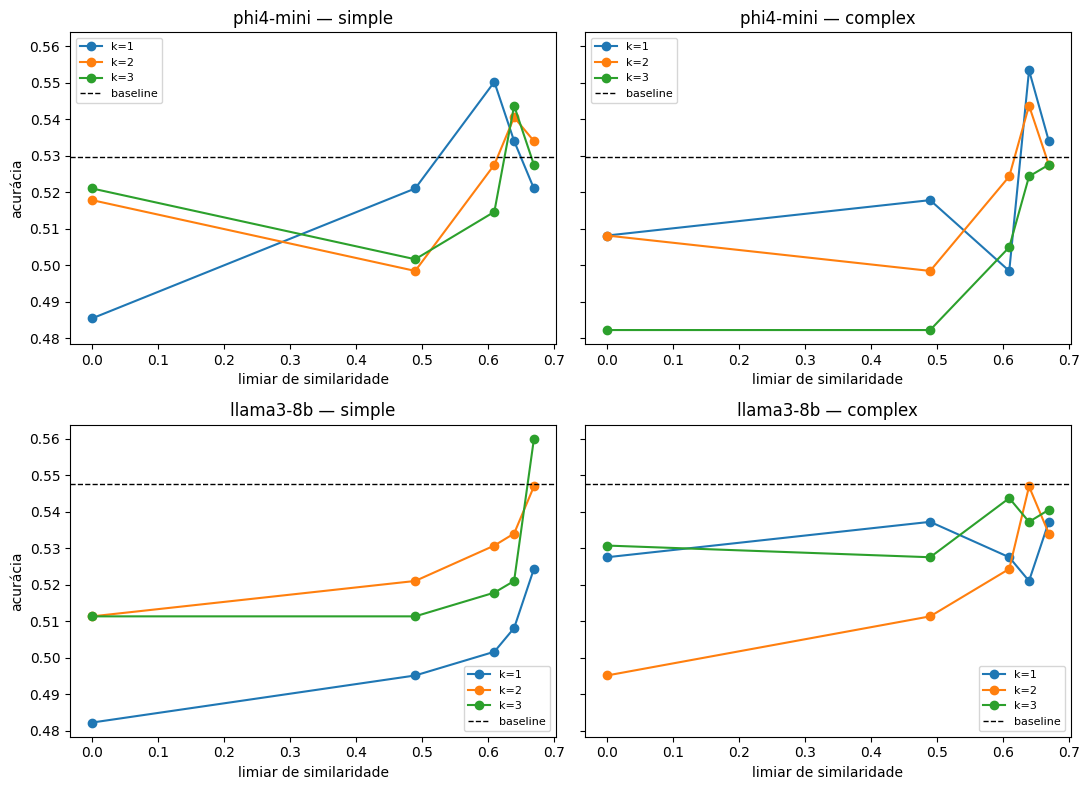

In [26]:
fig, axes = plt.subplots(len(STUDENTS), len(DEPTHS), figsize=(11, 4 * len(STUDENTS)), sharey=True)
axes = np.atleast_2d(axes)

for i, student in enumerate(STUDENTS):
    base_acc = accuracy_block(list(baseline_rows[student].values()))["accuracy"]
    for j, depth in enumerate(DEPTHS):
        ax = axes[i, j]
        sub = summary_df[(summary_df["student"] == student) & (summary_df["depth"] == depth)]
        for k in sorted(sub["k"].unique()):
            line = sub[sub["k"] == k].sort_values("threshold")
            ax.plot(line["threshold"], line["accuracy"], marker="o", label=f"k={k}")
        ax.axhline(base_acc, color="black", linestyle="--", linewidth=1, label="baseline")
        ax.set_title(f"{student} — {depth}")
        ax.set_xlabel("limiar de similaridade")
        if j == 0:
            ax.set_ylabel("acurácia")
        ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### Mapa de calor: delta de acurácia (condição − baseline) por k × limiar

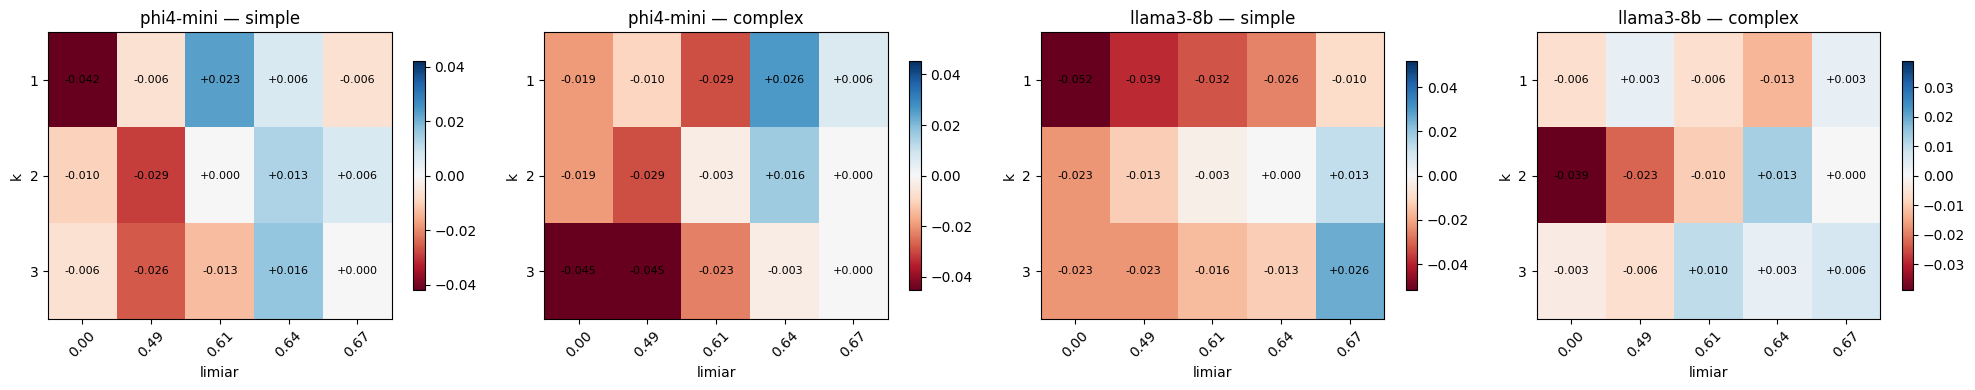

In [27]:
fig, axes = plt.subplots(1, len(STUDENTS) * len(DEPTHS), figsize=(5 * len(STUDENTS) * len(DEPTHS), 4))
axes = np.atleast_1d(axes)

panel = 0
for student in STUDENTS:
    for depth in DEPTHS:
        ax = axes[panel]
        panel += 1
        sub = summary_df[(summary_df["student"] == student) & (summary_df["depth"] == depth)]
        pivot = sub.pivot(index="k", columns="threshold", values="delta_accuracy")
        if pivot.dropna(how="all").empty:
            ax.set_title(f"{student} — {depth} (sem dados)")
            ax.axis("off")
            continue
        # nan-aware: uma grade rodada parcialmente (retomada depois) pode ter buracos.
        vmax = max(np.nanmax(np.abs(pivot.values)), 1e-6)
        im = ax.imshow(pivot.values, cmap="RdBu", vmin=-vmax, vmax=vmax, aspect="auto")
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f"{t:.2f}" for t in pivot.columns], rotation=45)
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xlabel("limiar")
        ax.set_ylabel("k")
        ax.set_title(f"{student} — {depth}")
        for (yi, xi), val in np.ndenumerate(pivot.values):
            ax.text(xi, yi, f"{val:+.3f}", ha="center", va="center", fontsize=8)
        fig.colorbar(im, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()


### Transferability: utility × similaridade (sem filtro de limiar, `threshold=0.0`)

A pergunta específica do LogiQA2 (ver introdução): a utility decai com a distância semântica
igual acontece no ARC, ou fica achatada/ruidosa — sinal de que "parecido" em texto não significa
"mesma estrutura de argumento" aqui? Usa `rmcq.stages.analyze.transferability`, as mesmas faixas
de similaridade (`SIM_BINS`) do resto do projeto.


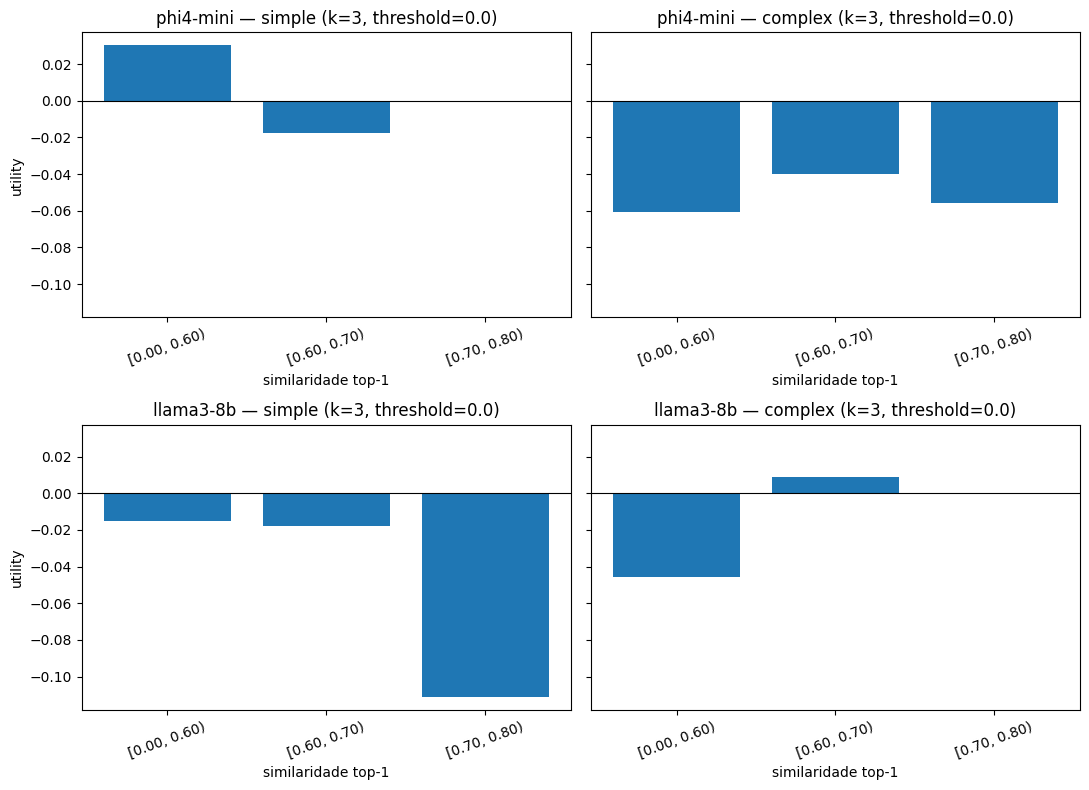

In [28]:
fig, axes = plt.subplots(len(STUDENTS), len(DEPTHS), figsize=(11, 4 * len(STUDENTS)), sharey=True)
axes = np.atleast_2d(axes)

for i, student in enumerate(STUDENTS):
    base = baseline_rows[student]
    for j, depth in enumerate(DEPTHS):
        ax = axes[i, j]
        # k mais alto disponível, sem filtro de limiar: mais chance de cada faixa de
        # similaridade ter itens suficientes para a métrica não ficar vazia.
        k_ref = max(K_GRID)
        rows = load_rows(diag_eval_path(student, student, depth, k_ref, 0.0))
        if not rows:
            continue
        bands = transferability(base, rows, SIM_BINS)
        band_df = pd.DataFrame(bands)
        ax.bar(band_df["sim_bin"], band_df["utility"])
        ax.axhline(0, color="black", linewidth=0.8)
        ax.set_title(f"{student} — {depth} (k={k_ref}, threshold=0.0)")
        ax.set_xlabel("similaridade top-1")
        ax.tick_params(axis="x", rotation=20)
        if j == 0:
            ax.set_ylabel("utility")

plt.tight_layout()
plt.show()


### Quantas reflexões o limiar realmente entrega (a pergunta de rastreio pedida)

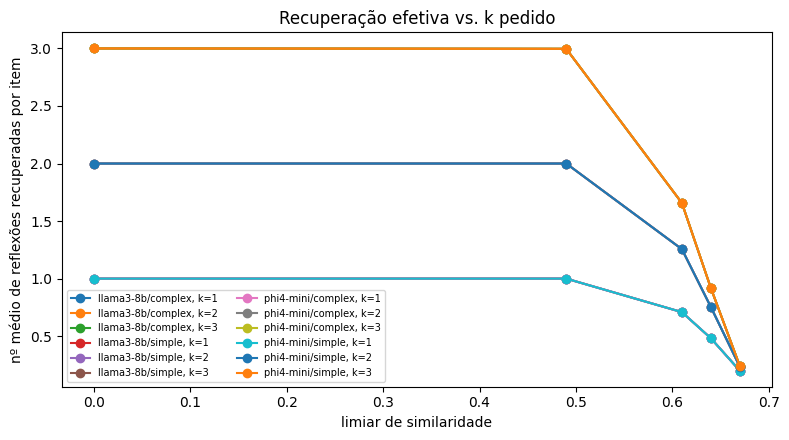

In [29]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for (student, depth), grp in coverage_df.groupby(["student", "depth"]):
    for k in sorted(grp["k"].unique()):
        line = grp[grp["k"] == k].sort_values("threshold")
        ax.plot(line["threshold"], line["mean_retrieved"], marker="o", label=f"{student}/{depth}, k={k}")

ax.set_xlabel("limiar de similaridade")
ax.set_ylabel("nº médio de reflexões recuperadas por item")
ax.set_title("Recuperação efetiva vs. k pedido")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()


## 13. Conclusões

Preencher depois de rodar a grade completa (não o smoke test):

- Alguma configuração bateu o baseline de forma consistente (`utility > 0` e `mcnemar_p`
  baixo) nos dois modelos, ou o ganho é específico de um aluno/profundidade?
- O padrão de `pct_fallback_baseline` (seções 7/12) explica os resultados? Com `k=2`
  explicitamente pedido, quantos itens realmente chegam com 2 reflexões em vez de 0 ou 1?
- Compare o gráfico de transferability deste notebook com o do ARC
  (`03_diagnostico_reflexao_arc_validacao.ipynb`): a utility decai com a similaridade do mesmo
  jeito nos dois datasets, ou o LogiQA2 (raciocínio) se comporta diferente do ARC (conhecimento)
  — confirmando ou refutando a hipótese da introdução, de que similaridade textual transfere
  pior quando o que importa é a estrutura do argumento, não o vocabulário?
- `USE_GRID_SAMPLE = True` rodou sobre uma amostra de Cochran do split de validação. Se os
  resultados forem promissores nessa amostra, vale rodar de novo com `USE_GRID_SAMPLE = False`
  (validação inteira) só nas configurações vencedoras, antes de tirar conclusões definitivas.
